In [1]:
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt
import pickle

In [2]:
TRAIN_DIRECTORY = "/kaggle/input/augmented-datasets/COVID_Augmented Photo Dataset Train/COVID_Augmented Photo Dataset Train"
TEST_DIRECTORY = "/kaggle/input/augmented-datasets/test/test"
CATEGORIES = ['covid','normal','virus']

# Training Data

In [3]:
IMG_SIZE = 256
CATEGORIES = ["covid", "normal", "virus"] 
TRAIN_DIRECTORY = "/kaggle/input/augmented-datasets/COVID_Augmented Photo Dataset Train/COVID_Augmented Photo Dataset Train"
train_data = []

for category in CATEGORIES:
    folder = os.path.join(TRAIN_DIRECTORY, category)
    label = CATEGORIES.index(category)
    
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        img_arr = cv2.imread(img_path)
        img_arr = cv2.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        train_data.append([img_arr, label])

In [4]:
len(train_data)


5828

In [5]:
random.shuffle(train_data)

# Test Data

In [6]:
IMG_SIZE=256
test_data=[]
for category in CATEGORIES:
    folder=os.path.join(TEST_DIRECTORY,category)
    label=CATEGORIES.index(category)
    for img in os.listdir(folder):
        img_path=os.path.join(folder,img)
        img_arr=cv2.imread(img_path)
        img_arr=cv2.resize(img_arr,(IMG_SIZE,IMG_SIZE))
        test_data.append([img_arr,label])

In [7]:
len(test_data)


366

In [8]:
X_train = []
X_test = []
y_train = []
y_test = []

In [9]:
for features, labels in train_data:
    X_train.append(features)
    y_train.append(labels)

In [10]:
for features, labels in test_data:
    X_test.append(features)
    y_test.append(labels)

In [11]:
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5828, 256, 256, 3), (366, 256, 256, 3), (5828,), (366,))

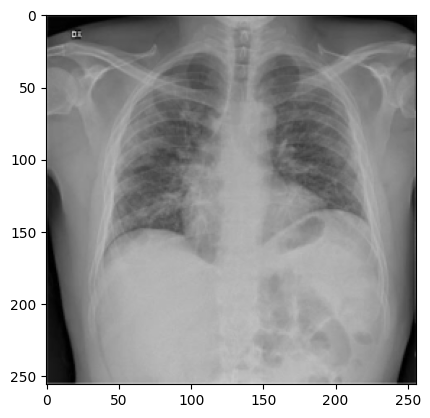

In [13]:
plt.imshow(X_test[0])

In [14]:
X_train[0].max()

254

# Rescale

In [15]:
X_train=X_train/255
X_test=X_test/255

In [16]:
X_train[0].max()

0.996078431372549

In [17]:
import tensorflow as tf
from tensorflow.keras import layers as L

2024-06-27 17:18:04.611017: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 17:18:04.611126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-27 17:18:04.737272: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [18]:
from keras.models import *
from keras.layers import *
import keras

In [19]:
from keras.layers import GlobalAveragePooling2D, Dense, Multiply
from keras import backend as K

# Attention Mechanism

In [20]:
def SqueezeAndExcitation(tensor, ratio = 16):
    nb_channel = tf.keras.backend.int_shape(tensor)[-1]

    x = GlobalAveragePooling2D()(tensor)
    x = Dense(nb_channel // ratio, activation='relu')(x)
    x = Dense(nb_channel, activation='sigmoid')(x)

    x = Multiply()([tensor, x])
    return x

In [21]:
class SpatialAttentionModule(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3):
        '''
        paper: https://arxiv.org/abs/1807.06521
        code: https://gist.github.com/innat/99888fa8065ecbf3ae2b297e5c10db70
        '''
        super(SpatialAttentionModule, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv2 = tf.keras.layers.Conv2D(32, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv3 = tf.keras.layers.Conv2D(16, kernel_size=kernel_size, 
                                            use_bias=False, 
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.nn.relu)
        self.conv4 = tf.keras.layers.Conv2D(1, kernel_size=kernel_size,  
                                            use_bias=False,
                                            kernel_initializer='he_normal',
                                            strides=1, padding='same', 
                                            activation=tf.math.sigmoid)

    def call(self, inputs):
        avg_out = tf.reduce_mean(inputs, axis=3)
        max_out = tf.reduce_max(inputs,  axis=3)
        x = tf.stack([avg_out, max_out], axis=3) 
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.conv4(x)
    

In [22]:
def se_sa(x):
    x_SE = SqueezeAndExcitation(x)
    x_sa = SpatialAttentionModule()(x)
    x2 = Multiply()([x_SE, x_sa])
    x3 = Add()([x, x2])
    return x3

if __name__ == "__main__":
    inputs = Input(shape=(256, 256, 3))
    y = se_sa(inputs)
    model = Model(inputs, y)

In [23]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 3)         │          0 │ input_layer[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 0)         │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │          3 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│                     │ 3)                │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention_… │ (None, 256, 256,  │     24,336 │ input_layer[0][0] │
│ (SpatialAttentionM… │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 256, 256,  │          0 │ multiply[0][0],   │
│ (Multiply)          │ 3)                │            │ spatial_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│                     │ 3)                │            │ multiply_1[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,339 (95.07 KB)

 Trainable params: 24,339 (95.07 KB)

 Non-trainable params: 0 (0.00 B)

# IRB Block

In [24]:
def inverted_residual_block(inputs, num_filters, strides=1, expansion_ratio=1):
    x_skip = se_sa(inputs)
    ## Point-Wise Convolution
    x = L.Conv2D(
        filters=expansion_ratio*inputs.shape[-1],
        kernel_size=1,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    ## Depth-Wise Convolution
    x = L.DepthwiseConv2D(
        kernel_size=3,
        strides=strides,
        padding="same",
        use_bias=False
    )(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    ## Point-Wise Convolution
    x = L.Conv2D(
        filters=num_filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)
    x = L.BatchNormalization()(x)

    ## Residual Connection
    if strides == 1 and (inputs.shape == x.shape):
        return L.Add()([x_skip, x])
    return x

In [25]:
inputs = Input(shape=(256, 256, 3))

# Inverted Residual Blocks
x = inverted_residual_block(inputs, num_filters=128, expansion_ratio=2)
x = MaxPooling2D((2, 2))(x)

x = inverted_residual_block(x, num_filters=256, expansion_ratio=2)
x = MaxPooling2D((2, 2))(x)

x = inverted_residual_block(x, num_filters=512, expansion_ratio=2)
x = MaxPooling2D((2, 2))(x)

x = SeparableConv2D(filters=256, kernel_size=(3, 3), strides=(2, 2))(x)
x = MaxPooling2D((2, 2))(x)


# Flatten and Fully Connected Layers
flatten = Flatten()(x)
x = Dense(units=512, activation='relu')(flatten)
x = BatchNormalization()(x)
x = Dense(units=256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dense(units=128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dense(units=64, activation='relu')(x)
outputs = Dense(units=3, activation='softmax')(x)

In [26]:
se_model = Model(inputs, outputs)
se_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 6)    │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 256, 256, 6)    │            54 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 128)  │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 256, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 256)  │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 128, 128, 256)  │         2,304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 256)  │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 512)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 512)    │         2,04

 Total params: 7,244,283 (27.63 MB)

 Trainable params: 7,237,603 (27.61 MB)

 Non-trainable params: 6,680 (26.09 KB)

In [27]:
from keras.optimizers import Adam


initial_lr = 0.0001
adam = Adam(learning_rate=initial_lr)

se_model.compile(optimizer=adam, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [28]:
class_weights = {0:2.9257028112449,
 1:2.3691056910569,
 2:0.9972621492128}

In [29]:
from keras.callbacks import ModelCheckpoint
filepath = "/kaggle/working/IRBmodel.keras"

In [30]:
checkpoint = ModelCheckpoint(filepath, monitor="val_accuracy", verbose=1, save_best_only="True", mode='max')

callbacks = [checkpoint]

In [31]:
history = se_model.fit(X_train, y_train,
 validation_data=[X_test, y_test],
 class_weight=class_weights,
callbacks = callbacks,
epochs=40, batch_size=32)

Epoch 1/40


I0000 00:00:1719508763.749159     107 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.7173 - loss: 1.2093

W0000 00:00:1719508819.322034     104 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update



Epoch 1: val_accuracy improved from -inf to 0.29508, saving model to /kaggle/working/IRBmodel.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 103s 353ms/step - accuracy: 0.7178 - loss: 1.2074 - val_accuracy: 0.2951 - val_loss: 1.5120
Epoch 2/40
182/183 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9007 - loss: 0.4616
Epoch 2: val_accuracy did not improve from 0.29508
183/183 ━━━━━━━━━━━━━━━━━━━━ 48s 260ms/step - accuracy: 0.9007 - loss: 0.4613 - val_accuracy: 0.2951 - val_loss: 2.5857
Epoch 3/40
182/183 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9328 - loss: 0.3193
Epoch 3: val_accuracy improved from 0.29508 to 0.30055, saving model to /kaggle/working/IRBmodel.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 48s 263ms/step - accuracy: 0.9328 - loss: 0.3194 - val_accuracy: 0.3005 - val_loss: 3.1904
Epoch 4/40
182/183 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9482 - loss: 0.2306
Epoch 4: val_accuracy improved from 0.30055 to 0.87158, saving model to /kaggle/working/IRBmodel.keras
183/183 ━━━━━━━━━

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [33]:
se_model.load_weights(filepath)

In [34]:
y_pred = se_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(conf_matrix)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step
Confusion Matrix:
[[108   0   0]
 [  1 132   1]
 [  0   5 119]]


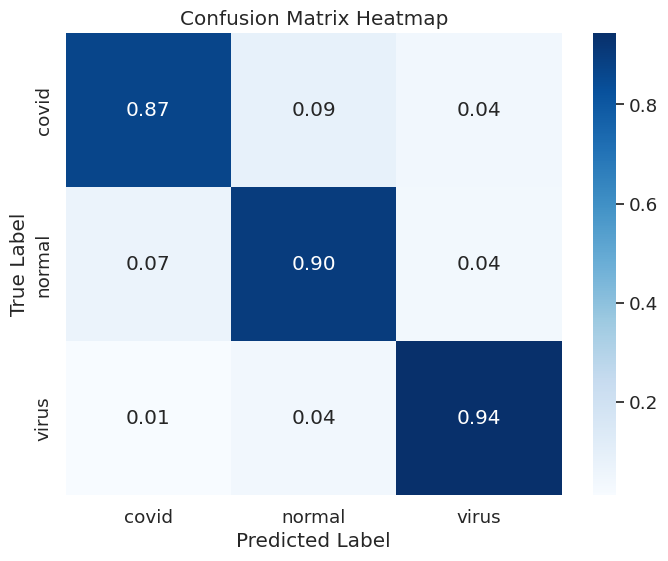

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example confusion matrix
conf_matrix = np.array([[100, 10, 5],
                        [15, 200, 8],
                        [2, 7, 150]])

# Define class labels
class_labels = ['covid', 'normal', 'virus']

# Normalize confusion matrix
conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='.2f', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
# Save the plot
plt.savefig('confusion_matrix_heatmap.png')

plt.show()

In [36]:
report = classification_report(y_test, y_pred_classes, target_names=CATEGORIES)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

       covid       0.99      1.00      1.00       108
      normal       0.96      0.99      0.97       134
       virus       0.99      0.96      0.98       124

    accuracy                           0.98       366
   macro avg       0.98      0.98      0.98       366
weighted avg       0.98      0.98      0.98       366



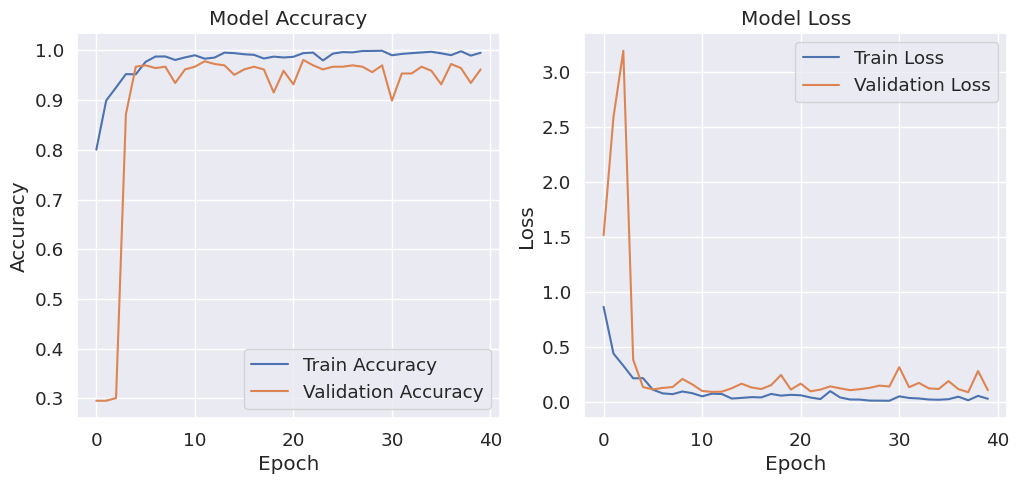

In [37]:
import matplotlib.pyplot as plt

# Function to plot training & validation accuracy and loss
def plot_history(history, model_name='model'):
    # Summarize history for accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='best')

    # Summarize history for loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='best')

    # Save the figure
    plt.savefig(f'{model_name}_accuracy_loss.png')
    plt.show()

# Call the function with your training history
plot_history(history, model_name='se_model')


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

import seaborn as sns

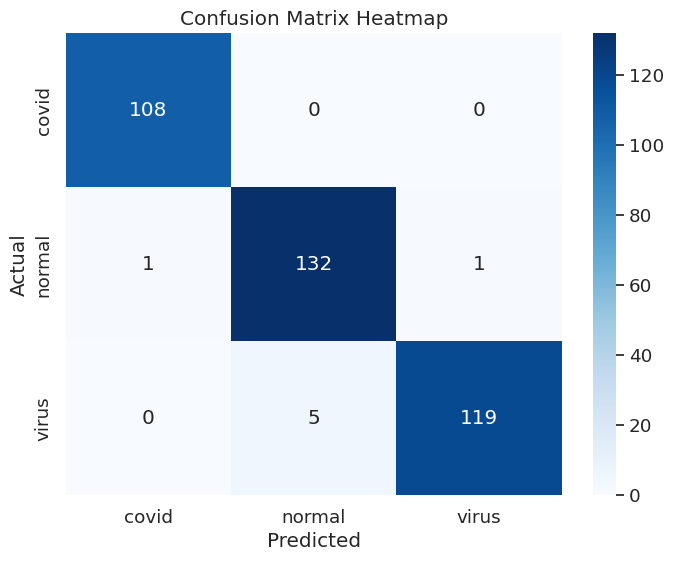

In [39]:
# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')

# Save heatmap as an image file
plt.savefig('confusion_matrix_heatmap2.png')

# Show plot
plt.show()

/tmp/ipykernel_34/3260696263.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


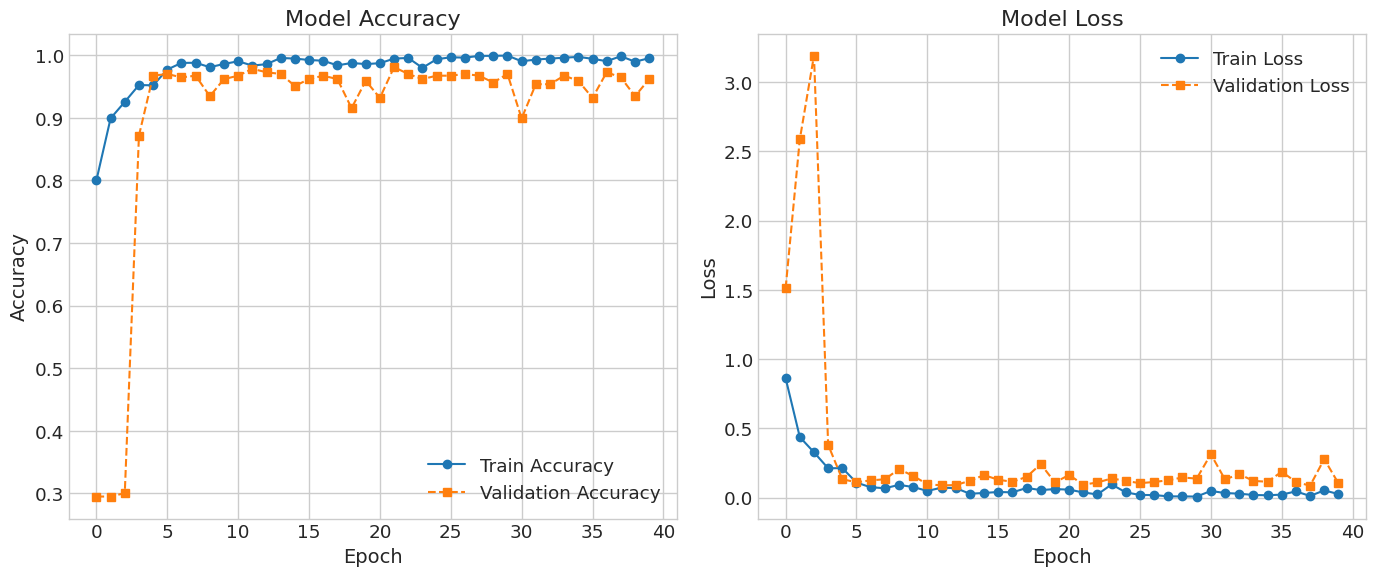

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot training & validation accuracy and loss
def plot_history(history, model_name='model'):
    # Set style
    plt.style.use('seaborn-whitegrid')

    # Set up figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='tab:blue', marker='o', linestyle='-')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='tab:orange', marker='s', linestyle='--')
    ax1.set_title('Model Accuracy', fontsize=16)
    ax1.set_ylabel('Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=14)
    ax1.legend(loc='lower right')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(history.history['loss'], label='Train Loss', color='tab:blue', marker='o', linestyle='-')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='tab:orange', marker='s', linestyle='--')
    ax2.set_title('Model Loss', fontsize=16)
    ax2.set_ylabel('Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=14)
    ax2.legend(loc='upper right')
    ax2.grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'{model_name}_accuracy_loss2.png', dpi=300)

    # Show plot
    plt.show()

# Call the function with your training history
plot_history(history, model_name='se_model')


In [41]:
# Assuming `history` contains your model's training history

# Retrieve the index of the epoch with the highest validation accuracy
max_val_acc_epoch = np.argmax(history.history['val_accuracy'])

# Add 1 to convert index to epoch number (epochs are 1-indexed)
max_val_acc_epoch_number = max_val_acc_epoch + 1

# Print or use the epoch number with the maximum validation accuracy
print(f"Epoch number with highest validation accuracy: {max_val_acc_epoch_number}")


Epoch number with highest validation accuracy: 22
